In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/processed.zip"
extract_path = "/content/yelp_data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped to:", extract_path)

Unzipped to: /content/yelp_data


In [3]:
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

In [4]:
class YelpFolderDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.image_paths = []
        self.transform = transform
        for label_folder in os.listdir(root_dir):
            folder_path = os.path.join(root_dir, label_folder)
            if os.path.isdir(folder_path):
                self.image_paths += [
                    os.path.join(folder_path, f)
                    for f in os.listdir(folder_path)
                    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
                ]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        return self.transform(img) if self.transform else img


In [5]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

In [6]:
train_folder = "/content/yelp_data/processed/train"
dataset = YelpFolderDataset(train_folder, transform)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

print(f"Loaded {len(dataset)} images from {train_folder}")

Loaded 160602 images from /content/yelp_data/processed/train


In [7]:
pip install diffusers accelerate transformers -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 53.4 MB/s eta 0:00:00


In [8]:
from diffusers import DDPMPipeline
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

pipeline = DDPMPipeline.from_pretrained("google/ddpm-cifar10-32").to(device)

print("DDPM model loaded on", device)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/180 [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/699 [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/256 [00:00<?, ?B/s]

diffusion_pytorch_model.bin:   0%|          | 0.00/143M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


DDPM model loaded on cpu


In [9]:
import matplotlib.pyplot as plt

os.makedirs("ddpm_generated", exist_ok=True)
generated_images = []

for i in range(5):
    image = pipeline().images[0]
    path = f"ddpm_generated/ddpm_image_{i+1}.png"
    image.save(path)
    generated_images.append(path)

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

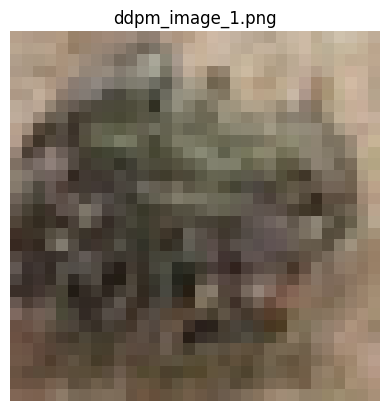

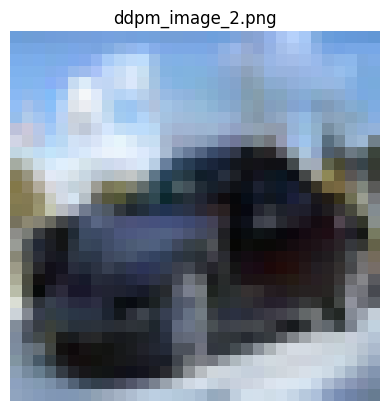

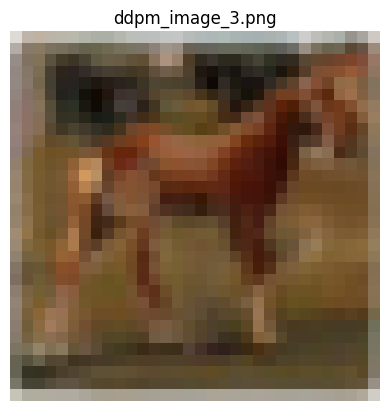

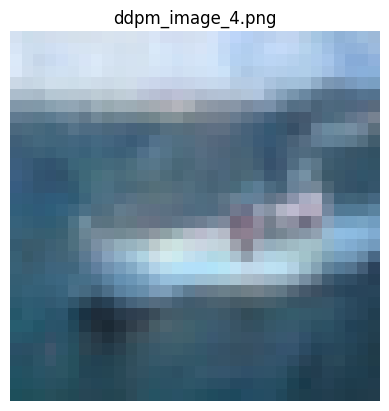

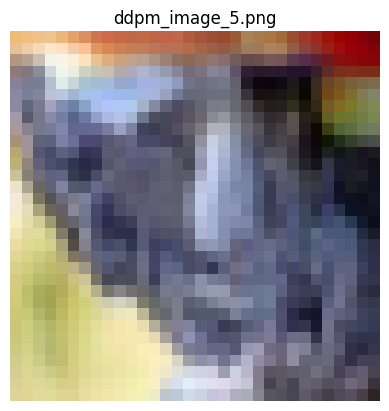

In [10]:
for img_path in generated_images:
    img = Image.open(img_path)
    plt.imshow(img)
    plt.axis("off")
    plt.title(os.path.basename(img_path))
    plt.show()

In [11]:
torch.save(pipeline.unet.state_dict(), "ddpm_generated/ddpm_unet_checkpoint.pth")

In [12]:
with open("ddpm_generated/ddpm_log.txt", "w") as f:
    f.write("Devanshi – DDPM \n")
    f.write("Model: google/ddpm-cifar10-32\n")
    f.write(f"Dataset: {train_folder} (5 class folders)\n")
    f.write("Generated 5 images\n")
    f.write("Saved UNet checkpoint\n")

print("Checkpoint and log saved.")

Checkpoint and log saved.
